In [1]:
import os, glob, json, math
from dataclasses import dataclass
from typing import Dict, List, Tuple, Iterable

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

print("torch:", torch.__version__, "cuda:", torch.cuda.is_available())


C:\Users\danielbelikov\anaconda3\envs\NavAlgorithms\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.5.1+cu121 cuda: True


In [2]:
@dataclass
class Cfg:
    data_root: str = "train"  # папка train/real_data + train/synth_data
    obs_len: int = 8
    pred_len: int = 12
    n_max: int = 10
    neighbor_radius: float = 10.0
    batch_size: int = 128
    lr: float = 1e-3
    epochs: int = 20
    num_workers: int = 0  # в ноутбуке обычно 0, чтобы не было проблем
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Cfg()
cfg


Cfg(data_root='train', obs_len=8, pred_len=12, n_max=10, neighbor_radius=10.0, batch_size=128, lr=0.001, epochs=20, num_workers=0, device='cuda')

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def collect_agent_frame_stats(path):
    """
    Returns:
      agent_frames: dict[pid] -> sorted list of frames where pid appears
      scene_primary_ids: set of p from 'scene' lines
      frame_minmax: (min_frame, max_frame) or None
    """
    scenes, tracks = load_trajnet_file(path)

    scene_primary_ids = set()
    for sc in scenes:
        scene_primary_ids.add(int(sc["p"]))

    agent_frames = defaultdict(list)
    for f, per_frame in tracks.items():
        f = int(f)
        for pid in per_frame.keys():
            agent_frames[int(pid)].append(f)

    # sort & unique
    for pid in list(agent_frames.keys()):
        agent_frames[pid] = sorted(set(agent_frames[pid]))

    frame_minmax = None
    if tracks:
        frame_minmax = (min(tracks.keys()), max(tracks.keys()))

    return agent_frames, scene_primary_ids, frame_minmax


def plot_histograms_for_file(path, bins_len=50, bins_df=50, max_df=50):
    agent_frames, scene_pids, frame_minmax = collect_agent_frame_stats(path)

    lengths_all = np.array([len(fr) for fr in agent_frames.values()], dtype=np.int64)

    # Δf по всем агентам
    dfs_all = []
    for fr in agent_frames.values():
        if len(fr) >= 2:
            dfs_all.extend(np.diff(fr).tolist())
    dfs_all = np.array(dfs_all, dtype=np.int64)

    # только primary agents из scene.p
    lengths_primary = []
    dfs_primary = []
    for pid in scene_pids:
        fr = agent_frames.get(pid, [])
        lengths_primary.append(len(fr))
        if len(fr) >= 2:
            dfs_primary.extend(np.diff(fr).tolist())
    lengths_primary = np.array(lengths_primary, dtype=np.int64)
    dfs_primary = np.array(dfs_primary, dtype=np.int64)

    print("File:", path)
    print("Agents total:", len(agent_frames))
    print("Primary agents in scenes:", len(scene_pids))
    print("Frames range in tracks:", frame_minmax)

    def describe(arr, name):
        if arr.size == 0:
            print(f"{name}: empty")
            return
        print(f"{name}: n={arr.size} min={arr.min()} p50={np.median(arr)} p90={np.quantile(arr, 0.9)} max={arr.max()}")

    describe(lengths_all, "lengths_all")
    describe(lengths_primary, "lengths_primary")
    describe(dfs_all, "df_all")
    describe(dfs_primary, "df_primary")

    # ---- plots ----
    plt.figure(figsize=(7,4))
    plt.hist(lengths_all, bins=bins_len)
    plt.title("Agent trajectory length (#frames present) — ALL agents")
    plt.xlabel("#frames with observations")
    plt.ylabel("count")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7,4))
    plt.hist(lengths_primary, bins=bins_len)
    plt.title("Agent trajectory length — PRIMARY agents (scene.p)")
    plt.xlabel("#frames with observations")
    plt.ylabel("count")
    plt.grid(True)
    plt.show()

    if dfs_all.size > 0:
        plt.figure(figsize=(7,4))
        plt.hist(np.clip(dfs_all, 1, max_df), bins=bins_df)
        plt.title(f"Δframe = f[t+1]-f[t] — ALL agents (clipped to {max_df})")
        plt.xlabel("Δframe")
        plt.ylabel("count")
        plt.grid(True)
        plt.show()

    if dfs_primary.size > 0:
        plt.figure(figsize=(7,4))
        plt.hist(np.clip(dfs_primary, 1, max_df), bins=bins_df)
        plt.title(f"Δframe — PRIMARY agents (scene.p) (clipped to {max_df})")
        plt.xlabel("Δframe")
        plt.ylabel("count")
        plt.grid(True)
        plt.show()


File: train\real_data\biwi_hotel.ndjson
Agents total: 263
Primary agents in scenes: 79
Frames range in tracks: (500, 17970)
lengths_all: n=263 min=1 p50=17.0 p90=28.80000000000001 max=85
lengths_primary: n=79 min=21 p50=24.0 p90=41.0 max=85
df_all: n=4358 min=10 p50=10.0 p90=10.0 max=10
df_primary: n=2190 min=10 p50=10.0 p90=10.0 max=10


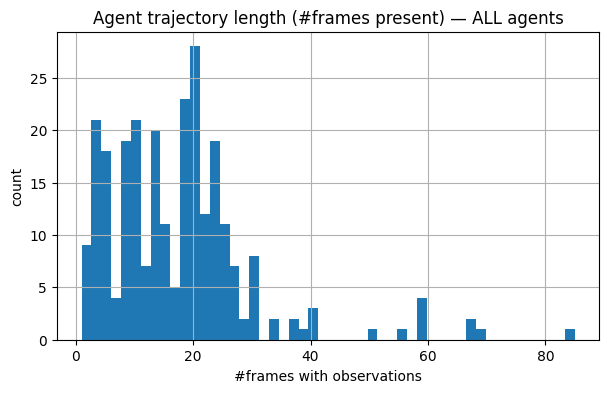

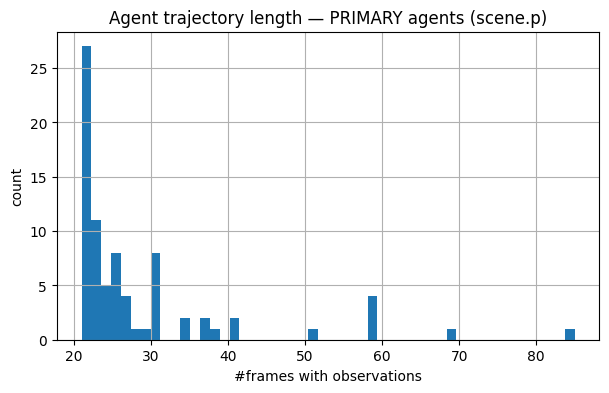

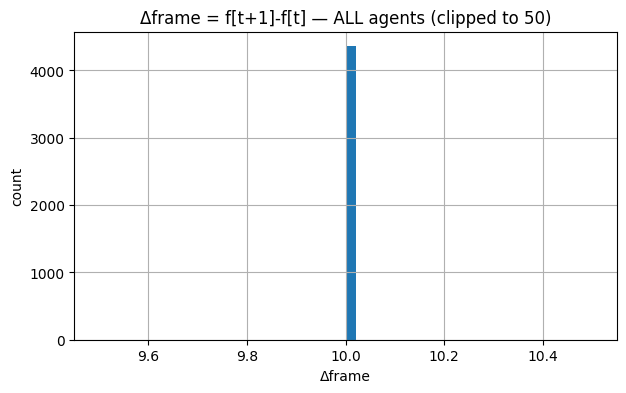

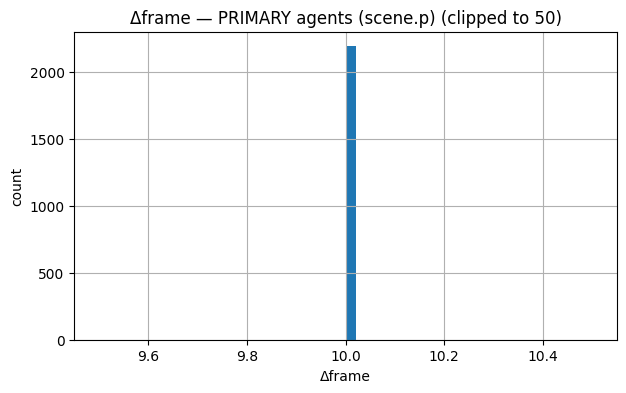

File: train\real_data\lcas.ndjson
Agents total: 304
Primary agents in scenes: 97
Frames range in tracks: (0, 906)
lengths_all: n=304 min=1 p50=13.0 p90=63.69999999999999 max=670
lengths_primary: n=97 min=21 p50=50.0 p90=131.2000000000001 max=670
df_all: n=9306 min=1 p50=1.0 p90=1.0 max=5
df_primary: n=7260 min=1 p50=1.0 p90=1.0 max=5


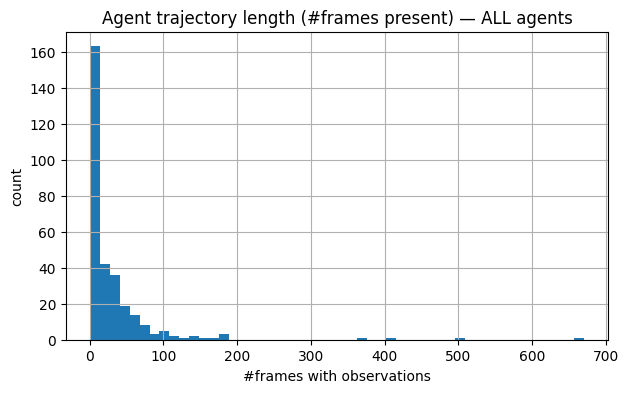

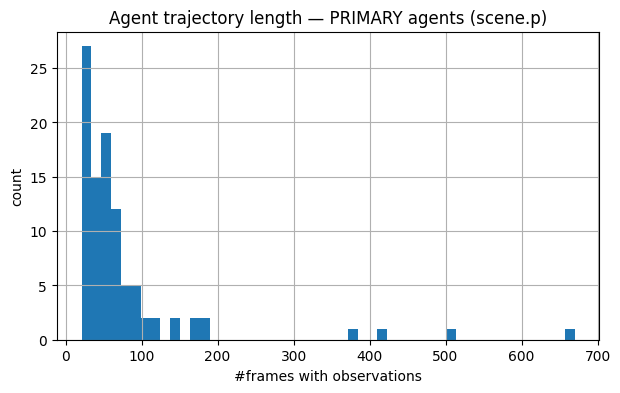

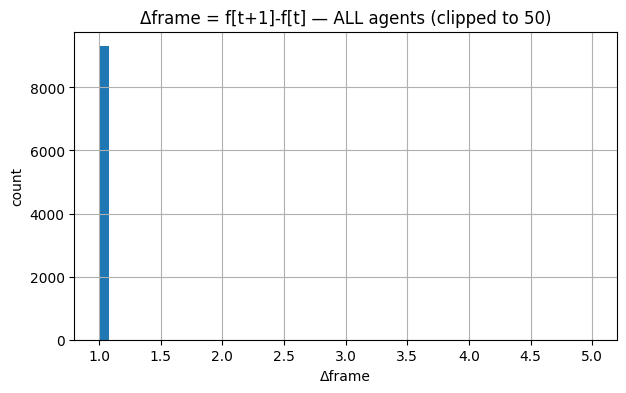

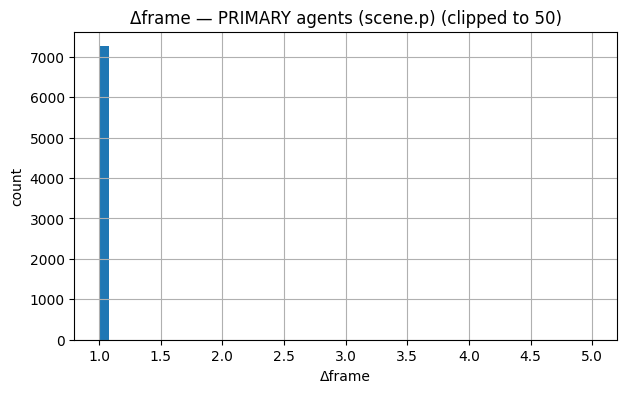

In [45]:
plot_histograms_for_file("train\\real_data\\biwi_hotel.ndjson")
plot_histograms_for_file("train\\real_data\\lcas.ndjson")


In [41]:
import numpy as np
from bisect import bisect_left

def build_agent_series_for_frames(
        tracks_by_frame: Dict[int, Dict[int, Tuple[float, float]]],
        pid: int,
        frames: List[int],
) -> Tuple[Optional[np.ndarray], Optional[np.ndarray], bool]:
    """
    Строит траекторию агента pid на заданных кадрах frames.
    Если в кадре нет точки — интерполирует между ближайшими известными, либо ffill/bfill.
    Returns:
      xy: [T,2] float32 (всегда заполнено)
      valid: [T] bool (True если точка была в исходном track, False если интерполяция/ffill/bfill)
      ok: False если у агента нет ни одной точки вообще.
    """
    # Собираем известные точки агента (по всем кадрам файла)
    known_frames = []
    known_xy = []
    for f, per_frame in tracks_by_frame.items():
        if pid in per_frame:
            known_frames.append(int(f))
            known_xy.append(per_frame[pid])

    if not known_frames:
        return None, None, False

    known_frames = np.asarray(known_frames, dtype=np.int64)
    known_xy = np.asarray(known_xy, dtype=np.float32)

    order = np.argsort(known_frames)
    known_frames = known_frames[order]
    known_xy = known_xy[order]
    kf = known_frames.tolist()

    T = len(frames)
    xy = np.zeros((T, 2), dtype=np.float32)
    valid = np.zeros((T,), dtype=bool)

    for i, f in enumerate(frames):
        f = int(f)
        per_frame = tracks_by_frame.get(f, None)
        if per_frame is not None and pid in per_frame:
            xy[i] = np.asarray(per_frame[pid], dtype=np.float32)
            valid[i] = True
            continue

        # интерполяция / ffill / bfill
        j = bisect_left(kf, f)
        if j == 0:
            # нет слева -> bfill
            xy[i] = known_xy[0]
        elif j == len(kf):
            # нет справа -> ffill
            xy[i] = known_xy[-1]
        else:
            f0, f1 = kf[j - 1], kf[j]
            p0, p1 = known_xy[j - 1], known_xy[j]
            if f1 == f0:
                xy[i] = p0
            else:
                a = (f - f0) / (f1 - f0)  # 0..1
                xy[i] = (1.0 - a) * p0 + a * p1
        # valid[i] остаётся False

    return xy, valid, True


In [42]:
def list_ndjson_paths(data_root: str) -> List[str]:
    patterns = [
        os.path.join(data_root, "real_data", "**", "*.ndjson"),
        os.path.join(data_root, "synth_data", "**", "*.ndjson"),
    ]
    paths = []
    for pat in patterns:
        paths.extend(glob.glob(pat, recursive=True))
    paths = sorted(set(paths))
    if not paths:
        raise RuntimeError(f"No .ndjson files found under {data_root}/real_data or {data_root}/synth_data")
    return paths


def iter_ndjson(path: str) -> Iterable[dict]:
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            yield json.loads(line)


def load_trajnet_file(path: str):
    """
    Supports common TrajNet++ NDJSON:
      {"scene": {"id":..., "p":..., "s":..., "e":..., "fps":...}}
      {"track": {"f":..., "p":..., "x":..., "y":...}}
    Returns:
      scenes: list of dicts
      tracks: dict frame -> dict ped_id -> (x,y)
    """
    scenes = []
    tracks: Dict[int, Dict[int, Tuple[float, float]]] = {}

    for obj in iter_ndjson(path):
        if "scene" in obj:
            scenes.append(obj["scene"])
        elif "track" in obj:
            tr = obj["track"]
            f = int(tr["f"])
            p = int(tr["p"])
            x = float(tr["x"])
            y = float(tr["y"])
            tracks.setdefault(f, {})[p] = (x, y)

    return scenes, tracks


def to_agent_centric(xy: np.ndarray):
    """
    xy: [T,2] absolute
    -> rel: [T,2] centered at last obs point and rotated by last heading
    """
    origin = xy[-1].copy()
    rel = xy - origin[None, :]

    if len(xy) >= 2:
        v = xy[-1] - xy[-2]
        theta = math.atan2(v[1], v[0]) if (abs(v[0]) + abs(v[1]) > 1e-6) else 0.0
    else:
        theta = 0.0

    c, s = math.cos(-theta), math.sin(-theta)
    R = np.array([[c, -s], [s, c]], dtype=np.float32)
    rel = (R @ rel.T).T.astype(np.float32)
    return rel, origin.astype(np.float32), theta, R


class TrajNetWindowDataset(Dataset):
    """
    Делает фиксированные окна длины obs_len+pred_len по плотной сетке кадров.
    Пропуски в track заполняются линейной интерполяцией/ffill/bfill.
    Добавлен sliding по сцене, чтобы из real-файлов получать достаточно семплов.
    """

    def __init__(
            self,
            ndjson_paths: List[str],
            obs_len: int,
            pred_len: int,
            n_max: int,
            neighbor_radius: float,
            stride: Optional[int] = None,
            max_windows_per_scene: Optional[int] = None,
            require_min_real_points_in_obs: int = 2,
    ):
        """
        stride: шаг sliding окон по времени (в кадрах). По умолчанию = obs_len.
        max_windows_per_scene: ограничение числа окон из одной сцены (полезно для огромной синтетики).
        require_min_real_points_in_obs: минимум реальных (неинтерполированных) точек у target в obs,
                                        иначе окно пропускаем (защита от полностью "сфабрикованных" obs).
        """
        self.obs_len = obs_len
        self.pred_len = pred_len
        self.n_max = n_max
        self.neighbor_radius = float(neighbor_radius)
        self.stride = int(stride) if stride is not None else int(obs_len)
        self.max_windows_per_scene = max_windows_per_scene
        self.require_min_real_points_in_obs = int(require_min_real_points_in_obs)

        self.samples: List[Dict[str, Any]] = []
        need = obs_len + pred_len

        for p in ndjson_paths:
            scenes, tracks = load_trajnet_file(p)
            if not scenes:
                continue
            if not tracks:
                raise RuntimeError(
                    f"No 'track' entries found in {p}. "
                    "Для обучения нужны 'track' строки с координатами."
                )

            # Предподсчёт min/max фрейма в файле — иногда помогает ограничить старт
            file_min_f = min(tracks.keys())
            file_max_f = max(tracks.keys())

            for sc in scenes:
                pid = int(sc["p"])
                s = int(sc["s"])
                e = int(sc["e"])

                # Пробуем трактовку e как exclusive (стандартно), но если сцена слишком короткая — попробуем inclusive
                # Здесь мы делаем sliding по start в пределах [s, e-need] (или [s, e-need+1] если inclusive)
                max_start_excl = e - need
                max_start_incl = (e + 1) - need

                if max_start_excl >= s:
                    start_min, start_max = s, max_start_excl
                    end_exclusive = True
                elif max_start_incl >= s:
                    start_min, start_max = s, max_start_incl
                    end_exclusive = False
                else:
                    continue

                # Ограничим старт рамками реально имеющихся фреймов в файле (защита от странных метаданных)
                start_min = max(start_min, file_min_f)
                start_max = min(start_max, file_max_f - need + 1)
                if start_max < start_min:
                    continue

                windows_added = 0
                for start in range(start_min, start_max + 1, self.stride):
                    frames = list(range(start, start + need))  # плотная сетка

                    # target series (interp/fill)
                    tgt_xy, tgt_valid, ok = build_agent_series_for_frames(tracks, pid, frames)
                    if not ok:
                        continue

                    # защита: если obs почти полностью интерполирован — пропускаем
                    if tgt_valid[:obs_len].sum() < self.require_min_real_points_in_obs:
                        continue

                    tgt_obs = tgt_xy[:obs_len]
                    tgt_fut = tgt_xy[obs_len:]

                    # agent-centric трансформация по observed части
                    tgt_obs_rel, origin, theta, R = to_agent_centric(tgt_obs)
                    tgt_fut_rel = (R @ (tgt_fut - origin[None, :]).T).T.astype(np.float32)

                    # позиция target на последнем obs шаге (интерполированная допустима)
                    tgt_last = tgt_xy[obs_len - 1]

                    # --- соседи ---
                    # Кандидаты соседей: те, кто присутствует в last_f (реально),
                    # чтобы не раздувать список всеми id файла. Это стандартная практичность.
                    last_f = frames[obs_len - 1]
                    cand_ids = []
                    per_last = tracks.get(last_f, {})
                    if per_last:
                        cand_ids = [nid for nid in per_last.keys() if int(nid) != pid]

                    # Если в last_f никого нет (редко), можно fallback:
                    # собрать соседей как union по obs_frames (дороже) — оставим простым.
                    picked = []
                    for nid in cand_ids:
                        # строим серию соседа только на obs кадрах
                        n_xy, n_valid, okn = build_agent_series_for_frames(tracks, int(nid), frames[:obs_len])
                        if not okn:
                            continue
                        # расстояние на последнем obs шаге (по интерполированному/реальному)
                        d = float(np.linalg.norm(n_xy[-1] - tgt_last))
                        if d <= self.neighbor_radius:
                            picked.append((d, int(nid), n_xy))

                    picked.sort(key=lambda x: x[0])
                    picked = picked[: self.n_max]

                    neigh_hist = np.zeros((self.n_max, obs_len, 2), dtype=np.float32)
                    neigh_mask = np.zeros((self.n_max,), dtype=np.float32)

                    for i, (_, nid, n_obs_xy) in enumerate(picked):
                        rel = (R @ (n_obs_xy - origin[None, :]).T).T.astype(np.float32)
                        neigh_hist[i] = rel
                        neigh_mask[i] = 1.0

                    self.samples.append(
                        {
                            "tgt_obs": tgt_obs_rel.astype(np.float32),
                            "tgt_fut": tgt_fut_rel.astype(np.float32),
                            "neigh_obs": neigh_hist,
                            "neigh_mask": neigh_mask,
                            # Если захочешь маски реальных точек:
                            # "tgt_obs_valid": tgt_valid[:obs_len].astype(np.float32),
                            # "tgt_fut_valid": tgt_valid[obs_len:].astype(np.float32),
                        }
                    )

                    windows_added += 1
                    if self.max_windows_per_scene is not None and windows_added >= self.max_windows_per_scene:
                        break

        if not self.samples:
            raise RuntimeError(
                "Не получилось собрать ни одного семпла. "
                "Проверь: (1) есть ли 'track' строки в NDJSON; "
                "(2) достаточно ли длина сцен для obs_len+pred_len; "
                "(3) корректны ли s/e; (4) не слишком ли строгие фильтры."
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return {
            "tgt_obs": torch.from_numpy(s["tgt_obs"]),         # [T_obs,2]
            "tgt_fut": torch.from_numpy(s["tgt_fut"]),         # [T_pred,2]
            "neigh_obs": torch.from_numpy(s["neigh_obs"]),     # [N,T_obs,2]
            "neigh_mask": torch.from_numpy(s["neigh_mask"]),   # [N]
            # если включишь маски:
            # "tgt_obs_valid": torch.from_numpy(s["tgt_obs_valid"]),  # [T_obs]
            # "tgt_fut_valid": torch.from_numpy(s["tgt_fut_valid"]),  # [T_pred]
        }


In [4]:
ndjson_paths = list_ndjson_paths(cfg.data_root)
print("ndjson files:", len(ndjson_paths))
print("example:", ndjson_paths[0])


ndjson files: 20
example: train\real_data\biwi_hotel.ndjson


In [19]:
import os, glob, random
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# фиксируем воспроизводимость
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def list_ndjson_paths(root: str):
    patterns = [
        os.path.join(root, "real_data", "**", "*.ndjson"),
        os.path.join(root, "synth_data", "**", "*.ndjson"),
    ]
    paths = []
    for pat in patterns:
        paths.extend(glob.glob(pat, recursive=True))
    paths = sorted(set(paths))
    if not paths:
        raise RuntimeError(f"No .ndjson files under {root}")
    return paths

train_paths_all = list_ndjson_paths("train")
test_paths_all  = list_ndjson_paths("test")  # если хочешь потом делать blind inference/qualitative

print("train ndjson:", len(train_paths_all))
print("test  ndjson:", len(test_paths_all))

# Разделение train -> train/val по ФАЙЛАМ (правильнее, чем по сэмплам)
random.shuffle(train_paths_all)
val_ratio = 0.10
split = max(1, int((1 - val_ratio) * len(train_paths_all)))
train_files = train_paths_all[:split]
val_files   = train_paths_all[split:]

print("train files:", len(train_files), "val files:", len(val_files))
print("example train:", train_files[0])
print("example val  :", val_files[0] if val_files else None)


train ndjson: 20
test  ndjson: 5
train files: 18 val files: 2
example train: train\synth_data\orca_synth.ndjson
example val  : train\real_data\biwi_hotel.ndjson


In [23]:
def file_has_track(path):
    n_scene = 0
    n_track = 0
    for obj in iter_ndjson(path):
        if "scene" in obj:
            n_scene += 1
        elif "track" in obj:
            n_track += 1
            break  # достаточно одного track, дальше не читаем
    return n_scene, n_track


good_paths = []
bad_paths = []
for p in train_paths_all:
    n_scene, n_track = file_has_track(p)
    if n_scene > 0 and n_track > 0:
        good_paths.append(p)
    else:
        bad_paths.append((p, n_scene, n_track))

print("Good:", len(good_paths))
print("Bad :", len(bad_paths))
print("Bad examples:", bad_paths[:5])


Good: 20
Bad : 0
Bad examples: []


In [27]:
import random

def count_samples_for_file(p, cfg):
    try:
        ds_tmp = TrajNetWindowDataset(
            ndjson_paths=[p],
            obs_len=cfg.obs_len,
            pred_len=cfg.pred_len,
            n_max=cfg.n_max,
            neighbor_radius=cfg.neighbor_radius,
        )
        return len(ds_tmp)
    except RuntimeError:
        return 0

train_paths_all = list_ndjson_paths("train")

counts = [(p, count_samples_for_file(p, cfg)) for p in train_paths_all]
usable = [(p, c) for p, c in counts if c > 0]

print("All files:", len(train_paths_all))
print("Usable files (c>0):", len(usable))
print("Top-5 by samples:", sorted(usable, key=lambda x: x[1], reverse=True)[:5])


All files: 20
Usable files (c>0): 2
Top-5 by samples: [('train\\synth_data\\orca_synth.ndjson', 54513), ('train\\real_data\\lcas.ndjson', 889)]


In [28]:
def split_train_val_by_samples(usable, val_ratio=0.1, min_val_samples=500, seed=42):
    """
    usable: list[(path, sample_count)]
    Returns: train_files, val_files
    """
    rng = random.Random(seed)
    usable = usable.copy()
    rng.shuffle(usable)

    total_samples = sum(c for _, c in usable)
    target_val_samples = max(min_val_samples, int(val_ratio * total_samples))

    val_files = []
    val_samples = 0
    for p, c in usable:
        if val_samples >= target_val_samples:
            break
        val_files.append(p)
        val_samples += c

    train_files = [p for p, _ in usable if p not in set(val_files)]
    return train_files, val_files, total_samples, val_samples, target_val_samples

train_files, val_files, total_s, val_s, target = split_train_val_by_samples(
    usable, val_ratio=0.1, min_val_samples=500, seed=42
)

print("Total samples:", total_s)
print("Val target samples:", target)
print("Val samples:", val_s, "Val files:", len(val_files))
print("Train files:", len(train_files))


Total samples: 55402
Val target samples: 5540
Val samples: 54513 Val files: 1
Train files: 1


In [29]:
def has_scene_and_track(path, max_lines=None):
    seen_scene = False
    seen_track = False
    for i, obj in enumerate(iter_ndjson(path)):
        if "scene" in obj:
            seen_scene = True
        elif "track" in obj:
            seen_track = True
            break
        if max_lines is not None and i >= max_lines:
            break
    return seen_scene, seen_track

bad = []
for p in train_paths_all:
    s, t = has_scene_and_track(p, max_lines=None)
    if not (s and t):
        bad.append((p, s, t))

print("Files without (scene and track):", len(bad))
for row in bad[:10]:
    print(row)


Files without (scene and track): 0


In [30]:
zero_files = [p for p in train_paths_all if count_samples_for_file(p, cfg) == 0]
print("zero_files:", len(zero_files))
print("example:", zero_files[:3])


zero_files: 18
example: ['train\\real_data\\biwi_hotel.ndjson', 'train\\real_data\\cff_06.ndjson', 'train\\real_data\\cff_07.ndjson']


In [31]:
def debug_file_build(path, obs_len, pred_len, limit_scenes=200):
    scenes, tracks = load_trajnet_file(path)
    if not scenes:
        return {"error": "no_scenes"}
    if not tracks:
        return {"error": "no_tracks"}

    need = obs_len + pred_len
    stats = {
        "file": path,
        "n_scenes_checked": 0,
        "ok": 0,
        "too_short": 0,
        "missing_tgt_obs": 0,
        "missing_tgt_fut": 0,
        "no_pid_in_range": 0,
        "example_scene": None,
        "example_pid_frames_in_range": None,
        "example_track_frame_minmax": (min(tracks.keys()), max(tracks.keys())),
    }

    for sc in scenes[:limit_scenes]:
        stats["n_scenes_checked"] += 1
        pid = int(sc["p"])
        s = int(sc["s"]); e = int(sc["e"])

        # какие кадры реально есть у pid в этом диапазоне (по факту track)
        pid_frames_in_range = [f for f in tracks.keys() if s <= f < e and pid in tracks[f]]
        if len(pid_frames_in_range) < need:
            stats["no_pid_in_range"] += 1
            if stats["example_scene"] is None:
                stats["example_scene"] = sc
                stats["example_pid_frames_in_range"] = len(pid_frames_in_range)
            continue

        # текущая (строгая) логика — требуем непрерывные range(s,e)
        frames = list(range(s, e))
        if len(frames) < need:
            frames = list(range(s, e + 1))
        if len(frames) < need:
            stats["too_short"] += 1
            continue

        fr = frames[:need]
        obs_frames = fr[:obs_len]
        fut_frames = fr[obs_len:]

        ok = all((f in tracks and pid in tracks[f]) for f in obs_frames)
        if not ok:
            stats["missing_tgt_obs"] += 1
            continue

        ok = all((f in tracks and pid in tracks[f]) for f in fut_frames)
        if not ok:
            stats["missing_tgt_fut"] += 1
            continue

        stats["ok"] += 1

    return stats

print(debug_file_build(zero_files[0], cfg.obs_len, cfg.pred_len))


{'file': 'train\\real_data\\biwi_hotel.ndjson', 'n_scenes_checked': 200, 'ok': 0, 'too_short': 0, 'missing_tgt_obs': 200, 'missing_tgt_fut': 0, 'no_pid_in_range': 0, 'example_scene': None, 'example_pid_frames_in_range': None, 'example_track_frame_minmax': (500, 17970)}


In [34]:
import os, glob, random
from dataclasses import dataclass
from typing import List, Tuple, Dict

@dataclass
class SplitPaths:
    train: List[str]
    val: List[str]
    test: List[str]

def list_ndjson_paths_split(root: str, use_real: bool = True, use_synth: bool = True) -> List[str]:
    pats = []
    if use_real:
        pats.append(os.path.join(root, "real_data", "**", "*.ndjson"))
    if use_synth:
        pats.append(os.path.join(root, "synth_data", "**", "*.ndjson"))
    paths = []
    for pat in pats:
        paths.extend(glob.glob(pat, recursive=True))
    return sorted(set(paths))

def count_samples_for_file(p: str, cfg) -> int:
    try:
        ds_tmp = TrajNetWindowDataset(
            ndjson_paths=[p],
            obs_len=cfg.obs_len,
            pred_len=cfg.pred_len,
            n_max=cfg.n_max,
            neighbor_radius=cfg.neighbor_radius,
        )
        return len(ds_tmp)
    except RuntimeError:
        return 0


In [43]:
real_paths = list_ndjson_paths_split("train", use_real=True, use_synth=False)
print("real usable:", sum(c > 0 for _, c in real_counts), "/", len(real_counts))
print(sorted([(p, c) for p, c in real_counts if c > 0], key=lambda x: x[1], reverse=True)[:10])

real usable: 1 / 19
[('train\\real_data\\lcas.ndjson', 889)]


In [35]:
def make_train_val_split_no_official_val(
        dataset_root: str,
        cfg,
        val_ratio_real_samples: float = 0.1,
        min_val_real_samples: int = 500,
        seed: int = 42,
        use_synth_in_train: bool = True,
) -> Tuple[SplitPaths, Dict[str, int]]:
    rng = random.Random(seed)

    train_dir = os.path.join(dataset_root, "train")
    test_dir  = os.path.join(dataset_root, "test")

    real_train = list_ndjson_paths_split(train_dir, use_real=True, use_synth=False)
    synth_train = list_ndjson_paths_split(train_dir, use_real=False, use_synth=True) if use_synth_in_train else []
    test_real = list_ndjson_paths_split(test_dir, use_real=True, use_synth=False) if os.path.isdir(test_dir) else []

    if not real_train:
        raise RuntimeError("Не найдены real_data ndjson в train/real_data.")

    # считаем окна только по real (валидация будет real-only)
    real_counts = [(p, count_samples_for_file(p, cfg)) for p in real_train]
    real_usable = [(p, c) for p, c in real_counts if c > 0]

    if not real_usable:
        raise RuntimeError(
            "Ни один real-файл не даёт семплов. "
            "Это значит, что Dataset всё ещё не умеет собирать окна (скорее всего нужен pid_frames/sliding)."
        )

    total_real_samples = sum(c for _, c in real_usable)
    target_val_samples = max(min_val_real_samples, int(val_ratio_real_samples * total_real_samples))

    # перемешиваем real файлы и набираем val до target_val_samples
    rng.shuffle(real_usable)
    val_files = []
    val_samples = 0
    for p, c in real_usable:
        if val_samples >= target_val_samples:
            break
        val_files.append(p)
        val_samples += c

    train_real_files = [p for p, _ in real_usable if p not in set(val_files)]

    # синтетику добавляем только в train, но тоже фильтруем "даёт ли семплы"
    synth_usable = []
    if synth_train:
        synth_counts = [(p, count_samples_for_file(p, cfg)) for p in synth_train]
        synth_usable = [p for p, c in synth_counts if c > 0]

    train_files = train_real_files + synth_usable

    stats = {
        "real_files_total": len(real_train),
        "real_files_usable": len(real_usable),
        "real_samples_total": total_real_samples,
        "val_target_samples": target_val_samples,
        "val_real_samples": val_samples,
        "val_real_files": len(val_files),
        "train_real_files": len(train_real_files),
        "train_synth_files": len(synth_usable),
        "test_real_files": len(test_real),
    }

    return SplitPaths(train=train_files, val=val_files, test=test_real), stats


In [36]:
splits, stats = make_train_val_split_no_official_val(
    dataset_root=".",  # там где лежат train/ и test/
    cfg=cfg,
    val_ratio_real_samples=0.1,
    min_val_real_samples=500,
    seed=42,
    use_synth_in_train=True,
)
stats


{'real_files_total': 19,
 'real_files_usable': 1,
 'real_samples_total': 889,
 'val_target_samples': 500,
 'val_real_samples': 889,
 'val_real_files': 1,
 'train_real_files': 0,
 'train_synth_files': 1,
 'test_real_files': 3}

In [38]:
real_paths = list_ndjson_paths_split("train", use_real=True, use_synth=False)
real_counts = [(p, count_samples_for_file(p, cfg)) for p in real_paths]
real_usable = [(p, c) for p, c in real_counts if c > 0]

print("real files total:", len(real_paths))
print("real files usable:", len(real_usable))
print("top real:", sorted(real_usable, key=lambda x: x[1], reverse=True)[:10])
print("zero real examples:", [p for p, c in real_counts if c == 0][:5])


real files total: 19
real files usable: 1
top real: [('train\\real_data\\lcas.ndjson', 889)]
zero real examples: ['train\\real_data\\biwi_hotel.ndjson', 'train\\real_data\\cff_06.ndjson', 'train\\real_data\\cff_07.ndjson', 'train\\real_data\\cff_08.ndjson', 'train\\real_data\\cff_09.ndjson']


In [37]:
from torch.utils.data import DataLoader

train_ds = TrajNetWindowDataset(splits.train, cfg.obs_len, cfg.pred_len, cfg.n_max, cfg.neighbor_radius)
val_ds   = TrajNetWindowDataset(splits.val,   cfg.obs_len, cfg.pred_len, cfg.n_max, cfg.neighbor_radius)

print("train_ds samples:", len(train_ds))
print("val_ds   samples:", len(val_ds))

train_dl = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                      num_workers=cfg.num_workers, drop_last=True, pin_memory=True)
val_dl   = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                      num_workers=cfg.num_workers, drop_last=False, pin_memory=True)


train_ds samples: 54513
val_ds   samples: 889


In [20]:
# train/val datasets
train_ds = TrajNetWindowDataset(
    ndjson_paths=train_files,
    obs_len=cfg.obs_len,
    pred_len=cfg.pred_len,
    n_max=cfg.n_max,
    neighbor_radius=cfg.neighbor_radius,
)
val_ds = TrajNetWindowDataset(
    ndjson_paths=val_files,
    obs_len=cfg.obs_len,
    pred_len=cfg.pred_len,
    n_max=cfg.n_max,
    neighbor_radius=cfg.neighbor_radius,
)

train_dl = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    drop_last=True,
    pin_memory=True,
)
val_dl = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    drop_last=False,
    pin_memory=True,
)

print("train samples:", len(train_ds), "val samples:", len(val_ds))


RuntimeError: Не получилось собрать ни одного семпла. Проверь: (1) есть ли 'track' строки в NDJSON; (2) достаточно ли длина сцен для obs_len+pred_len.

In [46]:
import os, glob, random
from dataclasses import dataclass
from typing import List, Dict, Tuple, Any, Optional

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


In [47]:
def list_ndjson_paths(split_dir: str, use_real=True, use_synth=True) -> List[str]:
    pats = []
    if use_real:
        pats.append(os.path.join(split_dir, "real_data", "**", "*.ndjson"))
    if use_synth:
        pats.append(os.path.join(split_dir, "synth_data", "**", "*.ndjson"))
    out = []
    for pat in pats:
        out.extend(glob.glob(pat, recursive=True))
    return sorted(set(out))

train_real = list_ndjson_paths("train", use_real=True, use_synth=False)
train_synth = list_ndjson_paths("train", use_real=False, use_synth=True)
test_real = list_ndjson_paths("test", use_real=True, use_synth=False) if os.path.isdir("test") else []

print("train_real:", len(train_real))
print("train_synth:", len(train_synth))
print("test_real:", len(test_real))


train_real: 19
train_synth: 1
test_real: 3


In [48]:
def build_agent_track_by_observation_index(
        tracks_by_frame: Dict[int, Dict[int, Tuple[float, float]]],
        pid: int,
        frame_min: Optional[int] = None,
        frame_max: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Возвращает:
      frames: [T] int64  — отсортированные frame-id, где есть pid
      xy:     [T,2] float32 — соответствующие координаты
    Ограничение по кадрам frame_min/frame_max применяется по frame-id.
    """
    frames = []
    pts = []
    for f, per in tracks_by_frame.items():
        f = int(f)
        if frame_min is not None and f < frame_min:
            continue
        if frame_max is not None and f > frame_max:
            continue
        if pid in per:
            frames.append(f)
            pts.append(per[pid])

    if not frames:
        return np.zeros((0,), dtype=np.int64), np.zeros((0,2), dtype=np.float32)

    order = np.argsort(frames)
    frames = np.asarray(frames, dtype=np.int64)[order]
    xy = np.asarray(pts, dtype=np.float32)[order]
    return frames, xy


def choose_neighbors_at_time_index(
        tracks_by_frame: Dict[int, Dict[int, Tuple[float, float]]],
        tgt_frame: int,
        tgt_pos: np.ndarray,  # [2]
        pid: int,
        neighbor_radius: float,
        n_max: int,
) -> List[int]:
    """
    Выбираем соседей по реальным наблюдениям в конкретном frame-id (tgt_frame).
    Это соответствует твоей текущей логике и масштабируется.
    """
    per = tracks_by_frame.get(int(tgt_frame), {})
    out = []
    tx, ty = float(tgt_pos[0]), float(tgt_pos[1])
    r2 = neighbor_radius * neighbor_radius
    for nid, (x, y) in per.items():
        nid = int(nid)
        if nid == pid:
            continue
        dx = float(x) - tx
        dy = float(y) - ty
        if dx*dx + dy*dy <= r2:
            out.append(nid)
    return out[:n_max]


In [49]:
class TrajNetWindowDatasetObsIndex(Dataset):
    """
    Окна строим по индексу наблюдения (последовательность точек агента),
    а не по range(s,e) с шагом 1 по frame-id.

    Для каждой scene:
      - берём все точки target pid в [s,e] (по frame-id)
      - сортируем по frame-id
      - делаем sliding windows длины obs_len+pred_len по индексу наблюдения

    Соседи:
      - определяем соседей по радиусу на последнем obs шаге (используем его frame-id)
      - для каждого соседа собираем его точки на obs кадрах (если нет точки в кадре -> маска 0)
    """

    def __init__(
            self,
            ndjson_paths: List[str],
            obs_len: int,
            pred_len: int,
            n_max: int,
            neighbor_radius: float,
            stride: int = 1,                 # для "хочу больше окон" ставь 1 или 2; для быстрее — obs_len
            max_windows_per_scene: Optional[int] = None,
    ):
        self.obs_len = int(obs_len)
        self.pred_len = int(pred_len)
        self.n_max = int(n_max)
        self.neighbor_radius = float(neighbor_radius)
        self.stride = int(stride)
        self.max_windows_per_scene = max_windows_per_scene

        self.samples: List[Dict[str, Any]] = []
        need = self.obs_len + self.pred_len

        for p in ndjson_paths:
            scenes, tracks = load_trajnet_file(p)
            if not scenes:
                continue
            if not tracks:
                continue

            for sc in scenes:
                pid = int(sc["p"])
                s = int(sc["s"])
                e = int(sc["e"])

                # трактуем e как exclusive сначала, но если точек мало — попробуем inclusive
                frames_ex, xy_ex = build_agent_track_by_observation_index(tracks, pid, frame_min=s, frame_max=e-1)
                frames_in, xy_in = build_agent_track_by_observation_index(tracks, pid, frame_min=s, frame_max=e)

                frames, xy = (frames_ex, xy_ex) if len(frames_ex) >= len(frames_in) else (frames_in, xy_in)

                L = len(frames)
                if L < need:
                    continue

                windows_added = 0
                # sliding windows по индексу наблюдения
                for k in range(0, L - need + 1, self.stride):
                    obs_xy = xy[k : k + self.obs_len]
                    fut_xy = xy[k + self.obs_len : k + need]

                    # agent-centric
                    tgt_obs_rel, origin, theta, R = to_agent_centric(obs_xy)
                    tgt_fut_rel = (R @ (fut_xy - origin[None, :]).T).T.astype(np.float32)

                    # last obs frame-id
                    last_frame = int(frames[k + self.obs_len - 1])
                    tgt_last_pos = obs_xy[-1]

                    neigh_ids = choose_neighbors_at_time_index(
                        tracks_by_frame=tracks,
                        tgt_frame=last_frame,
                        tgt_pos=tgt_last_pos,
                        pid=pid,
                        neighbor_radius=self.neighbor_radius,
                        n_max=self.n_max,
                    )

                    neigh_hist = np.zeros((self.n_max, self.obs_len, 2), dtype=np.float32)
                    neigh_mask = np.zeros((self.n_max,), dtype=np.float32)

                    # собираем соседей на тех же obs кадрах (по frame-id)
                    obs_frames = frames[k : k + self.obs_len]
                    for i, nid in enumerate(neigh_ids):
                        pts = []
                        ok = True
                        for f in obs_frames:
                            per = tracks.get(int(f), None)
                            if per is None or int(nid) not in per:
                                ok = False
                                break
                            pts.append(per[int(nid)])
                        if not ok:
                            continue
                        pts = np.asarray(pts, dtype=np.float32)
                        rel = (R @ (pts - origin[None, :]).T).T.astype(np.float32)
                        neigh_hist[i] = rel
                        neigh_mask[i] = 1.0

                    self.samples.append({
                        "tgt_obs": tgt_obs_rel.astype(np.float32),
                        "tgt_fut": tgt_fut_rel.astype(np.float32),
                        "neigh_obs": neigh_hist,
                        "neigh_mask": neigh_mask,
                    })

                    windows_added += 1
                    if self.max_windows_per_scene is not None and windows_added >= self.max_windows_per_scene:
                        break

        if not self.samples:
            raise RuntimeError("Не удалось собрать ни одного семпла. Проверь load_trajnet_file/to_agent_centric и пути.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return {
            "tgt_obs": torch.from_numpy(s["tgt_obs"]),
            "tgt_fut": torch.from_numpy(s["tgt_fut"]),
            "neigh_obs": torch.from_numpy(s["neigh_obs"]),
            "neigh_mask": torch.from_numpy(s["neigh_mask"]),
        }


In [57]:
# def count_samples_file_obsindex(path, obs_len, pred_len, n_max, neighbor_radius, stride=1):
#     try:
#         ds = TrajNetWindowDatasetObsIndex(
#             [path], obs_len=obs_len, pred_len=pred_len,
#             n_max=n_max, neighbor_radius=neighbor_radius,
#             stride=stride
#         )
#         return len(ds)
#     except RuntimeError:
#         return 0

def count_samples_file_obsindex(path, obs_len, pred_len, stride=1):
    scenes, tracks = load_trajnet_file(path)
    if not scenes or not tracks:
        return 0

    need = obs_len + pred_len
    total = 0

    # Предкешируем кадры для каждого pid (один раз на файл)
    pid_to_frames = {}
    for f, per in tracks.items():
        f = int(f)
        for pid in per.keys():
            pid = int(pid)
            pid_to_frames.setdefault(pid, []).append(f)

    # сортировка
    for pid in pid_to_frames:
        pid_to_frames[pid] = sorted(pid_to_frames[pid])

    for sc in scenes:
        pid = int(sc["p"])
        s = int(sc["s"])
        e = int(sc["e"])

        frames = pid_to_frames.get(pid, [])
        if not frames:
            continue

        # ограничиваем по s/e (exclusive vs inclusive)
        frames_ex = [f for f in frames if s <= f < e]
        frames_in = [f for f in frames if s <= f <= e]
        frames_use = frames_ex if len(frames_ex) >= len(frames_in) else frames_in

        L = len(frames_use)
        if L < need:
            continue

        # sliding windows по индексу наблюдения
        total += (L - need) // stride + 1

    return total


# подставь свои cfg.* если есть
obs_len = cfg.obs_len
pred_len = cfg.pred_len
n_max = 2
neighbor_radius = cfg.neighbor_radius

real_counts = [(p, count_samples_file_obsindex(p, obs_len, pred_len, stride=8)) for p in train_real]
real_usable = [(p,c) for p,c in real_counts if c>0]

print("real total:", len(train_real))
print("real usable:", len(real_usable))
print("top10 real:")
for p,c in sorted(real_usable, key=lambda x:x[1], reverse=True)[:10]:
    print(c, p)


real total: 19
real usable: 19
top10 real:
24100 train\real_data\cff_07.ndjson
23936 train\real_data\cff_12.ndjson
23751 train\real_data\cff_06.ndjson
23376 train\real_data\cff_14.ndjson
23070 train\real_data\cff_08.ndjson
22657 train\real_data\cff_15.ndjson
22355 train\real_data\cff_13.ndjson
22021 train\real_data\cff_18.ndjson
11433 train\real_data\cff_09.ndjson
10771 train\real_data\cff_16.ndjson


In [58]:
@dataclass
class SplitPaths:
    train: List[str]
    val: List[str]

def split_real_files_by_sample_target(real_files_with_counts, val_ratio=0.1, min_val_samples=2000, seed=42):
    rng = random.Random(seed)
    items = [(p,c) for p,c in real_files_with_counts if c>0]
    if not items:
        raise RuntimeError("Нет usable real файлов для split.")

    total = sum(c for _,c in items)
    target = max(min_val_samples, int(val_ratio * total))

    rng.shuffle(items)
    val = []
    s = 0
    for p,c in items:
        if s >= target:
            break
        val.append(p)
        s += c

    train = [p for p,_ in items if p not in set(val)]
    return train, val, total, s, target

train_real_files, val_files, total_real, val_real_s, target = split_real_files_by_sample_target(
    real_counts, val_ratio=0.1, min_val_samples=2000, seed=42
)

# train = оставшиеся real + вся synth (можно ограничить synth позже)
train_files = train_real_files + train_synth

print("Real total samples:", total_real)
print("Val target samples:", target, "Val real samples:", val_real_s)
print("Train real files:", len(train_real_files), "Val real files:", len(val_files))
print("Train total files:", len(train_files))


Real total samples: 240890
Val target samples: 24089 Val real samples: 43617
Train real files: 15 Val real files: 4
Train total files: 16


In [61]:
from torch.utils.data import DataLoader

# Рекомендация:
# - stride=1 даёт много окон (лучше качество, дольше)
# - stride=obs_len быстрее и меньше корреляции
train_stride = cfg.obs_len
val_stride = cfg.obs_len

train_ds = TrajNetWindowDatasetObsIndex(
    ndjson_paths=train_files,
    obs_len=cfg.obs_len,
    pred_len=cfg.pred_len,
    n_max=cfg.n_max,
    neighbor_radius=cfg.neighbor_radius,
    stride=train_stride,
    max_windows_per_scene=None,   # при необходимости ограничим синтетику отдельно
)

val_ds = TrajNetWindowDatasetObsIndex(
    ndjson_paths=val_files,
    obs_len=cfg.obs_len,
    pred_len=cfg.pred_len,
    n_max=cfg.n_max,
    neighbor_radius=cfg.neighbor_radius,
    stride=val_stride,
    max_windows_per_scene=None,
)

print("train_ds samples:", len(train_ds))
print("val_ds   samples:", len(val_ds))

train_dl = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    drop_last=True,
    pin_memory=True,
)

val_dl = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    drop_last=False,
    pin_memory=True,
)


train_ds samples: 251786
val_ds   samples: 43617


In [62]:
import torch

def ade_fde(pred, gt):
    """
    pred, gt: [B, T, 2]
    returns: (ADE, FDE) scalars
    """
    err = torch.linalg.norm(pred - gt, dim=-1)  # [B,T]
    ade = err.mean()
    fde = err[:, -1].mean()
    return ade, fde

def mse_loss(pred, gt):
    return torch.mean((pred - gt) ** 2)


In [63]:
class SocialGRUPredictor(nn.Module):
    def __init__(self, hidden=128, obs_len=8, pred_len=12):
        super().__init__()
        self.hidden = hidden
        self.obs_len = obs_len
        self.pred_len = pred_len

        self.enc_tgt = nn.GRU(input_size=2, hidden_size=hidden, batch_first=True)
        self.enc_neigh = nn.GRU(input_size=2, hidden_size=hidden, batch_first=True)

        self.fuse = nn.Sequential(
            nn.Linear(hidden + hidden, 256),
            nn.ReLU(),
            nn.Linear(256, hidden),
            nn.ReLU(),
        )

        self.dec = nn.GRU(input_size=2, hidden_size=hidden, batch_first=True)
        self.out = nn.Linear(hidden, 2)

    def forward(self, tgt_obs, neigh_obs, neigh_mask):
        # tgt_obs: [B,T,2], neigh_obs: [B,N,T,2], neigh_mask: [B,N]
        B, T, _ = tgt_obs.shape
        _, N, _, _ = neigh_obs.shape

        _, h_tgt = self.enc_tgt(tgt_obs)   # [1,B,H]
        h_tgt = h_tgt.squeeze(0)           # [B,H]

        neigh_flat = neigh_obs.reshape(B * N, T, 2)
        _, h_neigh = self.enc_neigh(neigh_flat)  # [1,B*N,H]
        h_neigh = h_neigh.squeeze(0).reshape(B, N, self.hidden)

        m = neigh_mask.unsqueeze(-1)  # [B,N,1]
        denom = m.sum(dim=1).clamp_min(1.0)
        h_social = (h_neigh * m).sum(dim=1) / denom  # [B,H]

        h0 = self.fuse(torch.cat([h_tgt, h_social], dim=-1))  # [B,H]
        h = h0.unsqueeze(0)  # [1,B,H]

        last = tgt_obs[:, -1, :]  # [B,2]
        preds = []
        x = last
        for _ in range(self.pred_len):
            out, h = self.dec(x.unsqueeze(1), h)
            dx = self.out(out.squeeze(1))
            x = x + dx
            preds.append(x.unsqueeze(1))
        return torch.cat(preds, dim=1)


In [64]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = SocialGRUPredictor(hidden=128, obs_len=cfg.obs_len, pred_len=cfg.pred_len).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=1e-4)


device: cuda


In [65]:
from tqdm import tqdm

def run_train_epoch(model, dl, optimizer):
    model.train()
    total_loss = 0.0
    total_ade = 0.0
    total_fde = 0.0
    n_batches = 0

    for batch in tqdm(dl, desc="train", leave=False):
        tgt_obs = batch["tgt_obs"].to(device).float()        # [B,T_obs,2]
        tgt_fut = batch["tgt_fut"].to(device).float()        # [B,T_pred,2]
        neigh_obs = batch["neigh_obs"].to(device).float()    # [B,N,T_obs,2]
        neigh_mask = batch["neigh_mask"].to(device).float()  # [B,N]

        pred = model(tgt_obs, neigh_obs, neigh_mask)         # [B,T_pred,2]

        loss = mse_loss(pred, tgt_fut)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        with torch.no_grad():
            ade, fde = ade_fde(pred, tgt_fut)

        total_loss += float(loss.item())
        total_ade += float(ade.item())
        total_fde += float(fde.item())
        n_batches += 1

    return {
        "loss": total_loss / max(1, n_batches),
        "ade": total_ade / max(1, n_batches),
        "fde": total_fde / max(1, n_batches),
    }

@torch.no_grad()
def run_eval_epoch(model, dl):
    model.eval()
    total_loss = 0.0
    total_ade = 0.0
    total_fde = 0.0
    n_batches = 0

    for batch in tqdm(dl, desc="val", leave=False):
        tgt_obs = batch["tgt_obs"].to(device).float()
        tgt_fut = batch["tgt_fut"].to(device).float()
        neigh_obs = batch["neigh_obs"].to(device).float()
        neigh_mask = batch["neigh_mask"].to(device).float()

        pred = model(tgt_obs, neigh_obs, neigh_mask)
        loss = mse_loss(pred, tgt_fut)
        ade, fde = ade_fde(pred, tgt_fut)

        total_loss += float(loss.item())
        total_ade += float(ade.item())
        total_fde += float(fde.item())
        n_batches += 1

    return {
        "loss": total_loss / max(1, n_batches),
        "ade": total_ade / max(1, n_batches),
        "fde": total_fde / max(1, n_batches),
    }


epoch 1/20 | train loss 0.9522 ADE 0.8810 FDE 1.7359 | val loss 0.9651 ADE 0.9079 FDE 1.8019


epoch 2/20 | train loss 0.8461 ADE 0.8145 FDE 1.6086 | val loss 0.9279 ADE 0.8851 FDE 1.7573


epoch 3/20 | train loss 0.8140 ADE 0.7936 FDE 1.5622 | val loss 0.9088 ADE 0.8619 FDE 1.7127


epoch 4/20 | train loss 0.7974 ADE 0.7806 FDE 1.5346 | val loss 0.9364 ADE 0.8987 FDE 1.7761


epoch 5/20 | train loss 0.7839 ADE 0.7730 FDE 1.5173 | val loss 0.9133 ADE 0.8759 FDE 1.7436


...

epoch 16/20 | train loss 0.6828 ADE 0.7193 FDE 1.4045 | val loss 0.8814 ADE 0.8460 FDE 1.6752


epoch 17/20 | train loss 0.6751 ADE 0.7163 FDE 1.3984 | val loss 0.9076 ADE 0.8698 FDE 1.7080


epoch 18/20 | train loss 0.6667 ADE 0.7125 FDE 1.3910 | val loss 0.8985 ADE 0.8596 FDE 1.6943


epoch 19/20 | train loss 0.6581 ADE 0.7092 FDE 1.3833 | val loss 0.8911 ADE 0.8452 FDE 1.6702


epoch 20/20 | train loss 0.6494 ADE 0.7057 FDE 1.3761 | val loss 0.8949 ADE 0.8508 FDE 1.6842


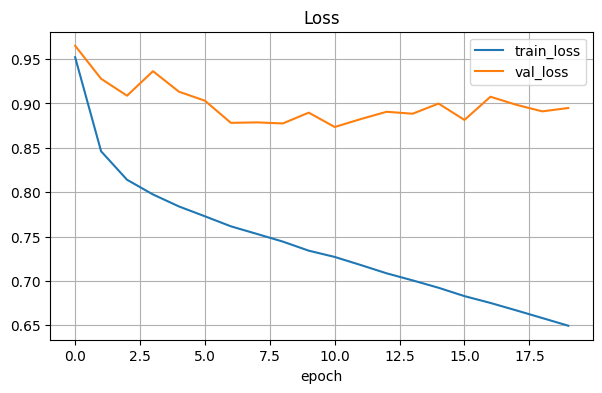

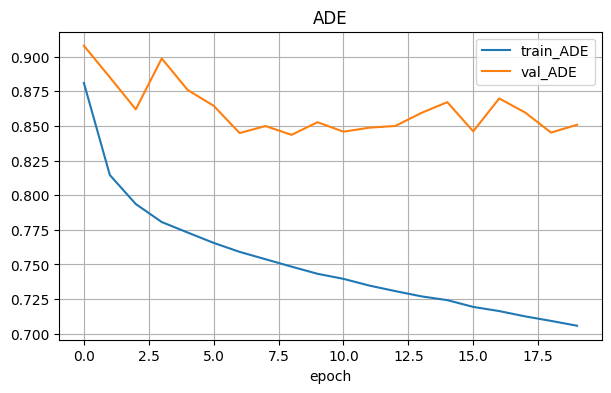

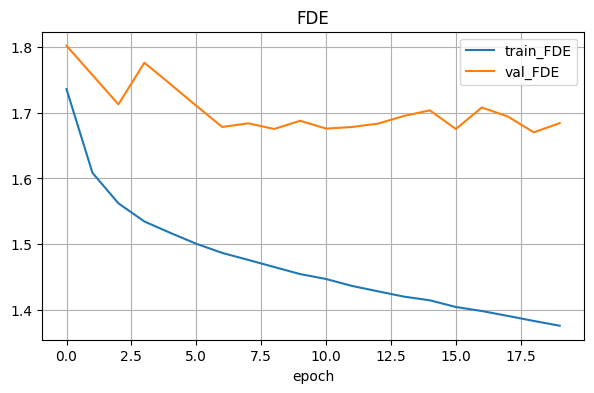

Best val ADE: 0.8435076780158404 saved to best_model.pt


In [66]:
history = {
    "train_loss": [],
    "train_ade": [],
    "train_fde": [],
    "val_loss": [],
    "val_ade": [],
    "val_fde": [],
}

best_val_ade = float("inf")
best_path = "best_model.pt"

for epoch in range(cfg.epochs):
    tr = run_train_epoch(model, train_dl, optimizer)
    va = run_eval_epoch(model, val_dl)

    history["train_loss"].append(tr["loss"])
    history["train_ade"].append(tr["ade"])
    history["train_fde"].append(tr["fde"])
    history["val_loss"].append(va["loss"])
    history["val_ade"].append(va["ade"])
    history["val_fde"].append(va["fde"])

    print(
        f"epoch {epoch+1}/{cfg.epochs} | "
        f"train loss {tr['loss']:.4f} ADE {tr['ade']:.4f} FDE {tr['fde']:.4f} | "
        f"val loss {va['loss']:.4f} ADE {va['ade']:.4f} FDE {va['fde']:.4f}"
    )

    # save best
    if va["ade"] < best_val_ade:
        best_val_ade = va["ade"]
        torch.save({"model": model.state_dict(), "cfg": vars(cfg)}, best_path)

# --- plots ---
plt.figure(figsize=(7,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.grid(True); plt.legend(); plt.title("Loss"); plt.xlabel("epoch")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history["train_ade"], label="train_ADE")
plt.plot(history["val_ade"], label="val_ADE")
plt.grid(True); plt.legend(); plt.title("ADE"); plt.xlabel("epoch")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history["train_fde"], label="train_FDE")
plt.plot(history["val_fde"], label="val_FDE")
plt.grid(True); plt.legend(); plt.title("FDE"); plt.xlabel("epoch")
plt.show()

print("Best val ADE:", best_val_ade, "saved to", best_path)


In [5]:
ds = TrajNetWindowDataset(
    ndjson_paths=ndjson_paths,
    obs_len=cfg.obs_len,
    pred_len=cfg.pred_len,
    n_max=cfg.n_max,
    neighbor_radius=cfg.neighbor_radius,
)
dl = DataLoader(ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, drop_last=True)
len(ds), len(dl)


(55402, 432)

In [7]:
model = SocialGRUPredictor(hidden=128, obs_len=cfg.obs_len, pred_len=cfg.pred_len).to(cfg.device)
opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
loss_fn = nn.SmoothL1Loss()


In [8]:
@torch.no_grad()
def ade_fde(pred, gt):
    # pred, gt: [B,T,2]
    err = torch.linalg.norm(pred - gt, dim=-1)  # [B,T]
    return err.mean().item(), err[:, -1].mean().item()


In [ ]:
import torch.nn as nn

loss_fn = nn.SmoothL1Loss()  # как у тебя

@torch.no_grad()
def evaluate(model, dl, device):
    model.eval()
    total_loss = 0.0
    total_ade = 0.0
    total_fde = 0.0
    n_batches = 0

    for batch in dl:
        tgt_obs = batch["tgt_obs"].to(device).float()
        tgt_fut = batch["tgt_fut"].to(device).float()
        neigh_obs = batch["neigh_obs"].to(device).float()
        neigh_mask = batch["neigh_mask"].to(device).float()

        pred = model(tgt_obs, neigh_obs, neigh_mask)

        loss = loss_fn(pred, tgt_fut).item()
        err = torch.linalg.norm(pred - tgt_fut, dim=-1)  # [B,T]
        ade = err.mean().item()
        fde = err[:, -1].mean().item()

        total_loss += loss
        total_ade += ade
        total_fde += fde
        n_batches += 1

    if n_batches == 0:
        return float("nan"), float("nan"), float("nan")

    return total_loss / n_batches, total_ade / n_batches, total_fde / n_batches


In [9]:
# model, optimizer должны быть уже созданы
# model = SocialGRUPredictor(...).to(cfg.device)
# opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)

train_loss_hist = []
val_loss_hist = []
val_ade_hist = []
val_fde_hist = []

best_val_ade = float("inf")

for epoch in range(1, cfg.epochs + 1):
    model.train()
    running = 0.0
    n_batches = 0

    pbar = tqdm(train_dl, desc=f"epoch {epoch}/{cfg.epochs}")
    for batch in pbar:
        tgt_obs = batch["tgt_obs"].to(cfg.device).float()
        tgt_fut = batch["tgt_fut"].to(cfg.device).float()
        neigh_obs = batch["neigh_obs"].to(cfg.device).float()
        neigh_mask = batch["neigh_mask"].to(cfg.device).float()

        pred = model(tgt_obs, neigh_obs, neigh_mask)
        loss = loss_fn(pred, tgt_fut)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        running += loss.item()
        n_batches += 1
        pbar.set_postfix(train_loss=running / n_batches)

    avg_train_loss = running / max(1, n_batches)
    train_loss_hist.append(avg_train_loss)

    # Валидация
    vloss, vade, vfde = evaluate(model, val_dl, cfg.device)
    val_loss_hist.append(vloss)
    val_ade_hist.append(vade)
    val_fde_hist.append(vfde)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={avg_train_loss:.4f} | "
        f"val_loss={vloss:.4f} | val_ADE={vade:.4f} | val_FDE={vfde:.4f}"
    )

    # Сохраняем лучший чекпоинт по val_ADE (можешь заменить на val_loss)
    if vade < best_val_ade:
        best_val_ade = vade
        os.makedirs("checkpoints", exist_ok=True)
        torch.save(
            {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "opt_state": opt.state_dict(),
                "cfg": cfg.__dict__,
                "best_val_ade": best_val_ade,
            },
            "checkpoints/best_by_val_ADE.pt",
        )
        print("  saved: checkpoints/best_by_val_ADE.pt")


epoch 1/20: 100%|██████████| 432/432 [00:05<00:00, 84.98it/s, loss=0.0902]


Epoch 1: ADE=0.3343, FDE=0.6890


epoch 2/20: 100%|██████████| 432/432 [00:04<00:00, 92.57it/s, loss=0.0631]


Epoch 2: ADE=0.3290, FDE=0.6622


epoch 3/20: 100%|██████████| 432/432 [00:05<00:00, 84.50it/s, loss=0.0592]


...

Epoch 18: ADE=0.2142, FDE=0.4254


epoch 19/20: 100%|██████████| 432/432 [00:04<00:00, 90.58it/s, loss=0.0417]


Epoch 19: ADE=0.2585, FDE=0.5236


epoch 20/20: 100%|██████████| 432/432 [00:05<00:00, 83.82it/s, loss=0.0412]

Epoch 20: ADE=0.3087, FDE=0.6064
Saved to checkpoints/social_gru_baseline.pt


In [ ]:
epochs = np.arange(1, len(train_loss_hist) + 1)

plt.figure(figsize=(7,4))
plt.plot(epochs, train_loss_hist, marker="o", label="train loss")
plt.plot(epochs, val_loss_hist, marker="o", label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss curves")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(epochs, val_ade_hist, marker="o", label="val ADE")
plt.xlabel("epoch")
plt.ylabel("ADE")
plt.title("Validation ADE")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(epochs, val_fde_hist, marker="o", label="val FDE")
plt.xlabel("epoch")
plt.ylabel("FDE")
plt.title("Validation FDE")
plt.grid(True)
plt.legend()
plt.show()


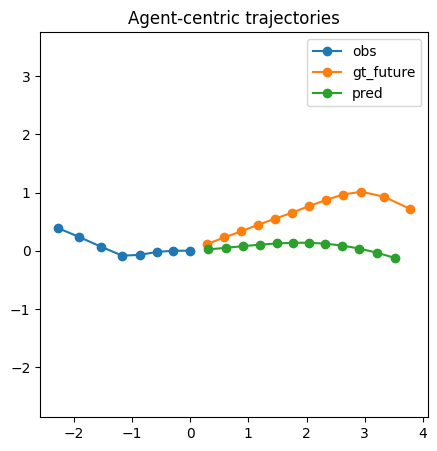

In [11]:
batch = next(iter(dl))
tgt_obs = batch["tgt_obs"][:1].to(cfg.device).float()      # [1,T_obs,2]
tgt_fut = batch["tgt_fut"][:1].to(cfg.device).float()      # [1,T_pred,2]
neigh_obs = batch["neigh_obs"][:1].to(cfg.device).float()  # [1,N,T_obs,2]
neigh_mask = batch["neigh_mask"][:1].to(cfg.device).float()

model.eval()
with torch.no_grad():
    pred = model(tgt_obs, neigh_obs, neigh_mask)

obs = tgt_obs.squeeze(0).cpu().numpy()
gt = tgt_fut.squeeze(0).cpu().numpy()
pr = pred.squeeze(0).cpu().numpy()

plt.figure(figsize=(5,5))
plt.plot(obs[:,0], obs[:,1], marker="o", label="obs")
plt.plot(gt[:,0], gt[:,1], marker="o", label="gt_future")
plt.plot(pr[:,0], pr[:,1], marker="o", label="pred")
plt.axis("equal")
plt.legend()
plt.title("Agent-centric trajectories")
plt.show()


In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_batch_examples(model, dl, cfg, n_show=9):
    batch = next(iter(dl))

    tgt_obs = batch["tgt_obs"][:n_show].to(cfg.device).float()
    tgt_fut = batch["tgt_fut"][:n_show].to(cfg.device).float()
    neigh_obs = batch["neigh_obs"][:n_show].to(cfg.device).float()
    neigh_mask = batch["neigh_mask"][:n_show].to(cfg.device).float()

    model.eval()
    with torch.no_grad():
        pred = model(tgt_obs, neigh_obs, neigh_mask)

    obs = tgt_obs.cpu().numpy()
    gt  = tgt_fut.cpu().numpy()
    pr  = pred.cpu().numpy()

    cols = int(np.ceil(np.sqrt(n_show)))
    rows = int(np.ceil(n_show / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = np.array(axes).reshape(-1)

    for i in range(n_show):
        ax = axes[i]
        ax.plot(obs[i,:,0], obs[i,:,1], "o-", label="obs")
        ax.plot(gt[i,:,0],  gt[i,:,1],  "o-", label="gt")
        ax.plot(pr[i,:,0],  pr[i,:,1],  "o-", label="pred")
        ax.axis("equal")
        ax.set_title(f"sample {i}")
        ax.legend()

    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


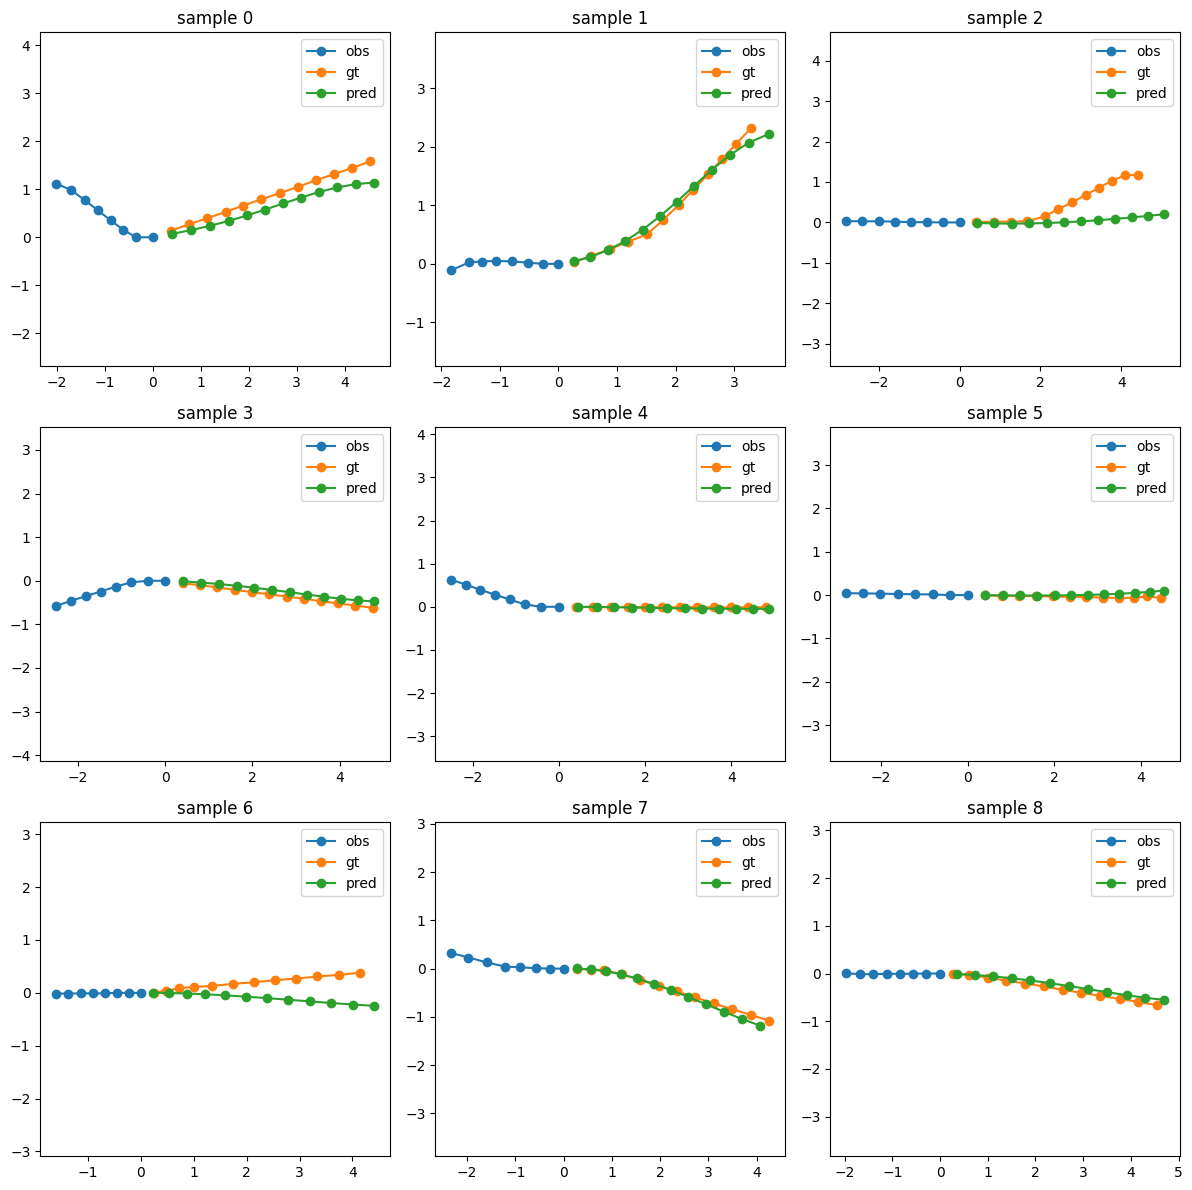

In [13]:
plot_batch_examples(model, dl, cfg, n_show=9)


In [14]:
def plot_with_neighbors(model, dl, cfg, idx=0):
    batch = next(iter(dl))

    tgt_obs = batch["tgt_obs"][idx:idx+1].to(cfg.device).float()
    tgt_fut = batch["tgt_fut"][idx:idx+1].to(cfg.device).float()
    neigh_obs = batch["neigh_obs"][idx:idx+1].to(cfg.device).float()
    neigh_mask = batch["neigh_mask"][idx:idx+1].to(cfg.device).float()

    model.eval()
    with torch.no_grad():
        pred = model(tgt_obs, neigh_obs, neigh_mask)

    obs = tgt_obs.squeeze(0).cpu().numpy()
    gt  = tgt_fut.squeeze(0).cpu().numpy()
    pr  = pred.squeeze(0).cpu().numpy()
    neigh = neigh_obs.squeeze(0).cpu().numpy()
    mask  = neigh_mask.squeeze(0).cpu().numpy()

    plt.figure(figsize=(5,5))

    # neighbors
    for i in range(neigh.shape[0]):
        if mask[i] < 0.5:
            continue
        plt.plot(neigh[i,:,0], neigh[i,:,1], "k--", alpha=0.4)

    plt.plot(obs[:,0], obs[:,1], "bo-", label="obs")
    plt.plot(gt[:,0],  gt[:,1],  "go-", label="gt")
    plt.plot(pr[:,0],  pr[:,1],  "ro-", label="pred")

    plt.scatter(0, 0, c="black", marker="x", label="ego @ t0")

    plt.axis("equal")
    plt.legend()
    plt.title("Agent-centric with neighbors")
    plt.show()


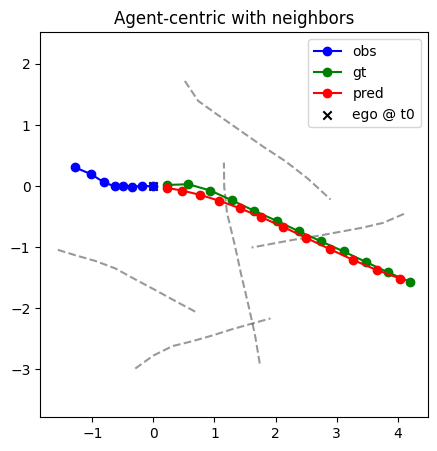

In [15]:
plot_with_neighbors(model, dl, cfg, idx=0)


In [17]:
def plot_error_over_time(model, dl, cfg, idx=0):
    batch = next(iter(dl))

    tgt_obs = batch["tgt_obs"][idx:idx+1].to(cfg.device).float()
    tgt_fut = batch["tgt_fut"][idx:idx+1].to(cfg.device).float()
    neigh_obs = batch["neigh_obs"][idx:idx+1].to(cfg.device).float()
    neigh_mask = batch["neigh_mask"][idx:idx+1].to(cfg.device).float()

    model.eval()
    with torch.no_grad():
        pred = model(tgt_obs, neigh_obs, neigh_mask)

    gt = tgt_fut.squeeze(0).cpu().numpy()
    pr = pred.squeeze(0).cpu().numpy()

    err = np.linalg.norm(pr - gt, axis=1)

    plt.figure(figsize=(6,3))
    plt.plot(err, marker="o")
    plt.xlabel("timestep")
    plt.ylabel("L2 error")
    plt.title("Prediction error over time")
    plt.grid(True)
    plt.show()


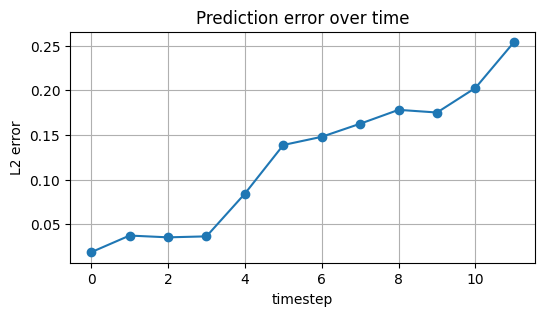

In [18]:
plot_error_over_time(model, dl, cfg, idx=0)
